Познакомимся с библиотекой requests, решив простую задачу — получить значения курсов валют. Курс валют — полезная и регулярно обновляемая информация, но каждый раз в ручном режиме получать информацию о курсе интересующей валюты трудоёмко.

Разработаем код, так называемый скрипт (англ. script, рус. сценарий), — небольшую программу, которая содержит последовательность действий для автоматического выполнения задачи.

С помощью скрипта мы будем в удобном виде выгружать информацию по курсам валют с заранее выбранного сайта.

Как только библиотека установлена, импортируем её и отправим наш первый запрос к ресурсу [Курсы валют ЦБ РФ в XML и JSON](https://www.cbr-xml-daily.ru/). Используем метод get() из библиотеки requests, передав ему соответствующий URL —  https://www.cbr-xml-daily.ru/daily_json.js:

In [21]:
import requests # Импортируем библиотеку requests
url = 'https://www.cbr-xml-daily.ru/daily_json.js' # Определяем значение URL страницы для запроса
response = requests.get(url) # Делаем GET-запрос к ресурсу и результат ответа сохраняем в переменной response

In [22]:
print(response) # Выводим значение response на экран как объект

<Response [200]>


In [23]:
print(response.status_code) # Выводим числовое значение response на экран

200


Текст ответа хранится в атрибуте text. Выведем значение атрибута на экран и посмотрим на его содержимое:

In [24]:
print(response.text) # Выводим содержимое атрибута text переменной response на экран

{"Date":"2026-03-17T11:30:00+03:00","PreviousDate":"2026-03-14T11:30:00+03:00","PreviousURL":"\/\/www.cbr-xml-daily.ru\/archive\/2026\/03\/14\/daily_json.js","Timestamp":"2026-03-16T18:00:00+03:00","Valute":{"AUD":{"ID":"R01010","NumCode":"036","CharCode":"AUD","Nominal":1,"Name":"Австралийский доллар","Value":56.7929,"Previous":56.6632},"AZN":{"ID":"R01020A","NumCode":"944","CharCode":"AZN","Nominal":1,"Name":"Азербайджанский манат","Value":47.6775,"Previous":47.1914},"DZD":{"ID":"R01030","NumCode":"012","CharCode":"DZD","Nominal":100,"Name":"Алжирских динаров","Value":61.182,"Previous":60.5958},"GBP":{"ID":"R01035","NumCode":"826","CharCode":"GBP","Nominal":1,"Name":"Фунт стерлингов","Value":107.3043,"Previous":107.0929},"AMD":{"ID":"R01060","NumCode":"051","CharCode":"AMD","Nominal":100,"Name":"Армянских драмов","Value":21.4758,"Previous":21.2495},"BHD":{"ID":"R01080","NumCode":"048","CharCode":"BHD","Nominal":1,"Name":"Бахрейнский динар","Value":215.5165,"Previous":213.3193},"BYN":

Для того чтобы удобно было работать с полученной информацией, нам необходимо преобразовать строку в словарь. В объект ответа Response  из библиотеки requests уже встроен метод json() .

Импортируем функцию pprint(), применим к полученному ответу метод json() и выведем полученный результат на экран:

In [25]:
from pprint import pprint # Импортируем функцию pprint()
import json # Импортируем модуль json
currencies = response.json() # Применяем метод json()
pprint(currencies) # Выводим результат на экран

{'Date': '2026-03-17T11:30:00+03:00',
 'PreviousDate': '2026-03-14T11:30:00+03:00',
 'PreviousURL': '//www.cbr-xml-daily.ru/archive/2026/03/14/daily_json.js',
 'Timestamp': '2026-03-16T18:00:00+03:00',
 'Valute': {'AED': {'CharCode': 'AED',
                    'ID': 'R01230',
                    'Name': 'Дирхам ОАЭ',
                    'Nominal': 1,
                    'NumCode': '784',
                    'Previous': 21.8449,
                    'Value': 22.0699},
            'AMD': {'CharCode': 'AMD',
                    'ID': 'R01060',
                    'Name': 'Армянских драмов',
                    'Nominal': 100,
                    'NumCode': '051',
                    'Previous': 21.2495,
                    'Value': 21.4758},
            'AUD': {'CharCode': 'AUD',
                    'ID': 'R01010',
                    'Name': 'Австралийский доллар',
                    'Nominal': 1,
                    'NumCode': '036',
                    'Previous': 56.6632,
            

Теперь данные находятся в словаре и можно легко получать необходимые значения.

Например, по ключу Valute мы можем обратиться к вложенному словарю, который содержит информацию о мировых валютах. Выведем на экран, например, информацию о евро (EUR):

In [26]:
pprint(currencies['Valute']['EUR']) # Выводим на экран информацию о валюте евро

{'CharCode': 'EUR',
 'ID': 'R01239',
 'Name': 'Евро',
 'Nominal': 1,
 'NumCode': '978',
 'Previous': 91.9847,
 'Value': 92.6555}


In [27]:
print(currencies['Valute']['CZK']['Name'])

Чешских крон


In [28]:
pprint(currencies['Valute']['USD'])

{'CharCode': 'USD',
 'ID': 'R01235',
 'Name': 'Доллар США',
 'Nominal': 1,
 'NumCode': '840',
 'Previous': 80.2254,
 'Value': 81.0517}


-------

## <center> Парсинг сайтов

Ресурс, с которым мы работали в предыдущем юните, возвращал ответ о текущем курсе валют в удобном, структурированном формате, из которого было легко извлечь необходимую информацию. Довольно часто для получения информации приходится обращаться напрямую к HTML-страницам.

Для примера рассмотрим страницу, содержащую статью с информацией о присуждении Нобелевской премии по экономике в 2021 году, и попробуем извлечь из неё заголовок статьи, опубликованной на странице, дату публикации, а также текст статьи.

Получить содержимое страницы в большинстве случаев несложно, гораздо труднее извлечь из HTML-кода нужную информацию

[Вы можете ознакомиться с информацией о HTML в справочнике](https://htmlbook.ru/html)

### Получаем содержимое веб-страницы

Получим HTML-код интересующей нас страницы.

Для этого отправим GET-запрос с помощью библиотеки requests и метода get() и посмотрим на текст ответа на наш запрос (как мы помним, он содержится в атрибуте text):

In [1]:
import requests # Импортируем библиотеку requests
url = 'https://nplus1.ru/news/2021/10/11/econobel2021' # Определяем адрес страницы
response = requests.get(url)  # Выполняем GET-запрос
print(response.text)  # Выводим содержимое атрибута text

<!DOCTYPE html><html lang="en-US"><head><title>Just a moment...</title><meta http-equiv="Content-Type" content="text/html; charset=UTF-8"><meta http-equiv="X-UA-Compatible" content="IE=Edge"><meta name="robots" content="noindex,nofollow"><meta name="viewport" content="width=device-width,initial-scale=1"><style>*{box-sizing:border-box;margin:0;padding:0}html{line-height:1.15;-webkit-text-size-adjust:100%;color:#313131;font-family:system-ui,-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,"Helvetica Neue",Arial,"Noto Sans",sans-serif,"Apple Color Emoji","Segoe UI Emoji","Segoe UI Symbol","Noto Color Emoji"}body{display:flex;flex-direction:column;height:100vh;min-height:100vh}.main-content{margin:8rem auto;padding-left:1.5rem;max-width:60rem}@media (width <= 720px){.main-content{margin-top:4rem}}#challenge-error-text{background-image:url("");background-repeat:no-repeat;background-size:contain;padding-left:34px}</style><meta http-equiv="refresh" content="360"></head><body><div class="mai

В отличие от предыдущего примера, где ответ возвращался в JSON-формате, мы не можем так просто преобразовать HTML-код в словарь и извлечь необходимую нам информацию.

Для решения таких задач в Python существует специальная библиотека ```BeautifulSoup```

## <center> Библиотека BeautifulSoup

In [2]:
from bs4 import BeautifulSoup # Импортируем библиотеку BeautifulSoup

Теперь мы можем извлекать данные из любой веб-страницы.

Ранее мы уже получили содержимое страницы с помощью GET-запроса и сохранили информацию в переменной response , теперь создадим объект BeautifulSoup с именем page, указывая в качестве параметра html.parser.

Для примера получим информацию o title (с англ. заголовок) — это строка, которая отображается на вкладке браузера:

In [3]:
import requests # Импортируем библиотеку requests
from bs4 import BeautifulSoup # Импортируем библиотеку BeautifulSoup
url = 'https://nplus1.ru/news/2021/10/11/econobel2021' # Определяем адрес страницы
response = requests.get(url, headers={'User-Agent': 'Chrome/144.0.0.0 YaBrowser/26.3.0.0 Safari/537.36'}) # Выполняем GET-запрос, содержимое ответа присваивается переменной response
page = BeautifulSoup(response.text, 'html.parser') # Создаём объект BeautifulSoup, указывая html-парсер
print(page.title) # Получаем тег title, отображающийся на вкладке браузера
print(page.title.text) # Выводим текст из полученного тега, который содержится в атрибуте text

<title>Just a moment...</title>
Just a moment...


Проблема в том, что сайт nplus1.ru (как и многие другие) использует защиту от ботов, например Cloudflare. Когда вы отправляете обычный GET-запрос через requests, сервер видит, что запрос не похож на браузер, и возвращает страницу с проверкой («Just a moment…»), которая требует выполнения JavaScript. Ваш код не умеет исполнять JS, поэтому получает только эту заглушку.
Почему так происходит?
 - Сервер проверяет наличие заголовков, куки, возможность выполнить JavaScript.
 - Библиотека requests не поддерживает JavaScript и не имитирует полноценный браузер.
 - BeautifulSoup просто парсит тот HTML, который вернул сервер, а это страница проверки.

Как это исправить?

Есть несколько способов обойти защиту:
1. Добавить заголовки, имитирующие браузер (самый простой)   - попробуйте этот вариант.
Часто помогает подстановка правильного User-Agent и других заголовков.

In [4]:
import requests
from bs4 import BeautifulSoup
url = 'https://nplus1.ru/news/2021/10/11/econobel2021'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
response = requests.get(url, headers=headers) 
page = BeautifulSoup(response.text, 'html.parser')
print(page.title)
print(page.title.text)

<title>Just a moment...</title>
Just a moment...


In [5]:
import requests # Импортируем библиотеку requests
from bs4 import BeautifulSoup # Импортируем библиотеку BeautifulSoup
url = 'https://nplus1.ru/news/2021/10/11/econobel2021' # Определяем адрес страницы
response = requests.get(url) # Выполняем GET-запрос, содержимое ответа присваивается переменной response
page = BeautifulSoup(response.text, 'html.parser') # Создаём объект BeautifulSoup, указывая html-парсер
print(page.title) # Получаем тег title, отображающийся на вкладке браузера
print(page.title.text) # Выводим текст из полученного тега, который содержится в атрибуте text

<title>Just a moment...</title>
Just a moment...


2. Использовать cloudscraper (библиотека, созданная специально для обхода Cloudflare)
Установите её:

pip install cloudscraper

In [6]:
import cloudscraper

url = 'https://nplus1.ru/news/2021/10/11/econobel2021'
scraper = cloudscraper.create_scraper()  # Создаём сессию, эмулирующую браузер
response = scraper.get(url)

# Если всё прошло успешно, код ответа будет 200
print(response.status_code)

# Далее можно работать с BeautifulSoup
from bs4 import BeautifulSoup
page = BeautifulSoup(response.text, 'html.parser')
print(page.title)
print(page.title.text)

403
<title>Just a moment...</title>
Just a moment...


In [ ]:
from playwright.sync_api import sync_playwright
def get_title():
    with sync_playwright() as p:
        browser = p.chromium.launch(headless=False)
        page = browser.new_page()
        page.goto('https://nplus1.ru/news/2021/10/11/econobel2021')
        page.wait_for_load_state('networkidle')
        title = page.title()
        browser.close()
        return title

print(get_title())

In [8]:
import cloudscraper
from bs4 import BeautifulSoup
scraper = cloudscraper.create_scraper()
url = 'https://nplus1.ru/news/2021/10/11/econobel2021'
response = scraper.get(url)
page = BeautifulSoup(response.text, 'html.parser')
print(page.title.text)
#cloudscraper имитирует работу браузера и решает головоломки Cloudflare.

Just a moment...


3. Попробуем использовать playwright (современная альтернатива Selenium)

Установка: pip install playwright 

In [ ]:
from playwright.sync_api import sync_playwright
with sync_playwright() as p:
    browser = p.chromium.launch(headless=False)
    page = browser.new_page()
    page.goto('https://nplus1.ru/news/2021/10/11/econobel2021')
    print(page.title())
    browser.close()

Пробуем еще, мы упорные ;)

In [ ]:
import asyncio
from playwright.async_api import async_playwright
async def get_title():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        await page.goto('https://nplus1.ru/news/2021/10/11/econobel2021')
        await page.wait_for_load_state('networkidle')
        title = await page.title()
        await browser.close()
        return title
title = await get_title()
print(title)

In [ ]:
import asyncio
from playwright.async_api import async_playwright

async def get_title():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)  # False, чтобы видеть браузер
        page = await browser.new_page()
        await page.goto('https://nplus1.ru/news/2021/10/11/econobel2021')
        await page.wait_for_load_state('networkidle')
        title = await page.title()
        await browser.close()
        return title

# В Jupyter можно напрямую использовать await
title = await get_title()
print(title)

In [ ]:
import asyncio
import sys
from playwright.async_api import async_playwright

async def get_title():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        await page.goto('https://nplus1.ru/news/2021/10/11/econobel2021')
        await page.wait_for_load_state('networkidle')
        title = await page.title()
        await browser.close()
        return title

if __name__ == "__main__":
    if sys.platform == "win32":
        asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
    try:
        result = asyncio.run(get_title())
        print(result)   # обязательно выводим
    except Exception as e:
        print(f"ERROR: {e}", file=sys.stderr)
        sys.exit(1)

Ситуация проясняется: сайт nplus1.ru теперь использует защиту (вероятно, Cloudflare), которая возвращает страницу с заголовком "Just a moment...". Это проверка браузера на наличие JavaScript. Мой запрос через requests работал, потому что, я заходил с IP, который пропускался без проверки (или работали сохранённые куки). У вас же запрос попал под защиту.

Библиотека requests не выполняет JavaScript, поэтому она не может пройти эту проверку и получает только страницу-заглушку. Чтобы получить реальный заголовок статьи, нужно использовать инструмент, который умеет исполнять JS и дожидаться завершения проверки — например, Playwright или Selenium. Чем сейчас и занимаемся.

In [ ]:
import asyncio
import sys
from playwright.async_api import async_playwright

async def get_title():
    async with async_playwright() as p:
        # Для отладки можно поставить headless=False, чтобы видеть, что происходит
        browser = await p.chromium.launch(headless=False)  # измените на True, когда заработает
        page = await browser.new_page()
        
        # Логируем ошибки и события сети
        page.on("pageerror", lambda exc: print(f"JS Error: {exc}"))
        page.on("requestfailed", lambda req: print(f"Request failed: {req.url} – {req.failure}"))
        
        try:
            # Увеличиваем таймаут навигации до 60 секунд
            await page.goto('https://nplus1.ru/news/2021/10/11/econobel2021', timeout=60000)
            
            # Ждём, пока исчезнет элемент с текстом "Just a moment" (или пока не появится что-то с article)
            # Это может занять несколько секунд, увеличим таймаут ожидания
            await page.wait_for_selector('text=Just a moment', state='detached', timeout=30000)
            
            # Теперь ждём появления заголовка статьи (например, h1 или meta-тег)
            # Можно дождаться конкретного элемента, который есть только на реальной странице
            await page.wait_for_selector('h1.article__title', timeout=10000)  # пример селектора, подберите под сайт
            
            # Получаем title
            title = await page.title()
            print(title)
            
            # Если нужно, можно вывести текст из конкретного тега (аналог page.title.text)
            # Но title уже даёт текст заголовка вкладки
            
        except Exception as e:
            print(f"Ошибка: {e}")
            # Делаем скриншот для анализа
            await page.screenshot(path='error.png')
            print("Скриншот сохранён как error.png")
        finally:
            await browser.close()

if __name__ == "__main__":
    if sys.platform == "win32":
        asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
    asyncio.run(get_title())

In [ ]:
from playwright.sync_api import sync_playwright

def get_title():
    with sync_playwright() as p:
        # Запускаем браузер в видимом режиме (headless=False), чтобы увидеть проверку Cloudflare
        browser = p.chromium.launch(headless=False)
        page = browser.new_page()
        
        # Переходим на страницу (таймаут 60 секунд)
        page.goto('https://nplus1.ru/news/2021/10/11/econobel2021', timeout=60000)
        
        # Ждём, пока исчезнет надпись "Just a moment..." (проверка пройдена)
        page.wait_for_selector('text=Just a moment', state='detached', timeout=30000)
        
        # Ждём появления заголовка статьи (селектор h1.article__title — уточните при необходимости)
        page.wait_for_selector('h1.article__title', timeout=10000)
        
        # Получаем title страницы (то, что во вкладке браузера)
        title = page.title()
        browser.close()
        return title

# Вызываем функцию и печатаем результат
print(get_title())

In [ ]:
import asyncio
import sys
from playwright.async_api import async_playwright
import nest_asyncio

# Разрешаем вложенные циклы asyncio (необходимо для работы в Jupyter)
nest_asyncio.apply()

async def get_title():
    async with async_playwright() as p:
        # Для отладки оставляем headless=False, потом можно сменить на True
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        
        # Логируем ошибки (опционально)
        page.on("pageerror", lambda exc: print(f"JS Error: {exc}"))
        
        # Переходим на страницу (таймаут 60 секунд)
        await page.goto('https://nplus1.ru/news/2021/10/11/econobel2021', timeout=60000)
        
        # Ждём, пока исчезнет "Just a moment..."
        await page.wait_for_selector('text=Just a moment', state='detached', timeout=30000)
        
        # Ждём появления заголовка статьи (селектор уточните при необходимости)
        await page.wait_for_selector('h1.article__title', timeout=10000)
        
        title = await page.title()
        await browser.close()
        return title

# Запускаем асинхронную функцию через asyncio.run() — теперь это допустимо благодаря nest_asyncio
if __name__ == "__main__":
    if sys.platform == "win32":
        asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
    result = asyncio.run(get_title())
    print(result)

---------------------------

Из-за капчи не работает обращение к сайту. Реализовать не получилось. Пропускаем

------------

### Извлекаем заголовок статьи

Выполним поставленную ранее задачу: получить информацию о странице и извлечь заголовок статьи, опубликованной на этой странице, дату публикации, а также текст статьи.

Предположим, что мы знаем, что в HTML-коде рассматриваемой нами страницы заголовок статьи заключён в тег ```<h1> … </h1>``` (заголовок первого уровня).

Тогда мы можем получить его текст с помощью метода find() (с англ. найти) объекта BeautifulSoup, передав ему название интересующего нас тега:

In [ ]:
# Применяем метод find() к объекту и выводим результат на экран
print(page.find('h1').text) 

AttributeError: 'NoneType' object has no attribute 'text'

Задание 5.4 (External resource)

Напишите функцию wiki_header, которая по адресу страницы возвращает заголовок первого уровня для статей на Wikipedia.

Функция wiki_header принимает один аргумент - url.
```python
wiki_header('https://en.wikipedia.org/wiki/Operating_system')
'Operating system'
```

In [ ]:
def wiki_header(url):
    url_split = url.split('/')[-1]
    return url_split.replace('_',' ')

wiki_header('https://ru.wikipedia.org/wiki/Pink_Floyd')

'Pink Floyd'

In [ ]:
# Эталонный ответ
def wiki_header(url):
    page=BeautifulSoup(requests.get(url).text,'html.parser')
    header=page.find('h1').text
    return header
wiki_header('https://ru.wikipedia.org/wiki/Pink_Floyd')

AttributeError: 'NoneType' object has no attribute 'text'

## Неуникальные теги: извлекаем текст и дату публикации статьи

Теперь получим сам текст статьи. Как вы уже знаете, первым делом необходимо определить, в какой тег он заключён. Применим, как и ранее, инструмент разработчика.

Видим, что искомый текст заключён в тег  ```<div> … </div> ```. Попробуем извлечь его уже известным нам способом — с помощью метода ```find()``` — и выведем его на экран.

In [ ]:
print(page.find('div').text) # Выводим содержимое атрибута text тега div

Enable JavaScript and cookies to continue


Мы увидели не то, что ожидали — кучу текста, не имеющего отношения к тому, что мы искали...

?
В чём же проблема?

Дело в том, что теги ```<div> … </div>``` очень распространённые и на странице их очень много. Метод find() нашёл первый из них, но это не то, что нам надо.

Посмотрим на нашу страницу, используя инструмент разработчика, ещё раз. Можем заметить, что у искомого текста есть свой класс — n1_material text-18 :

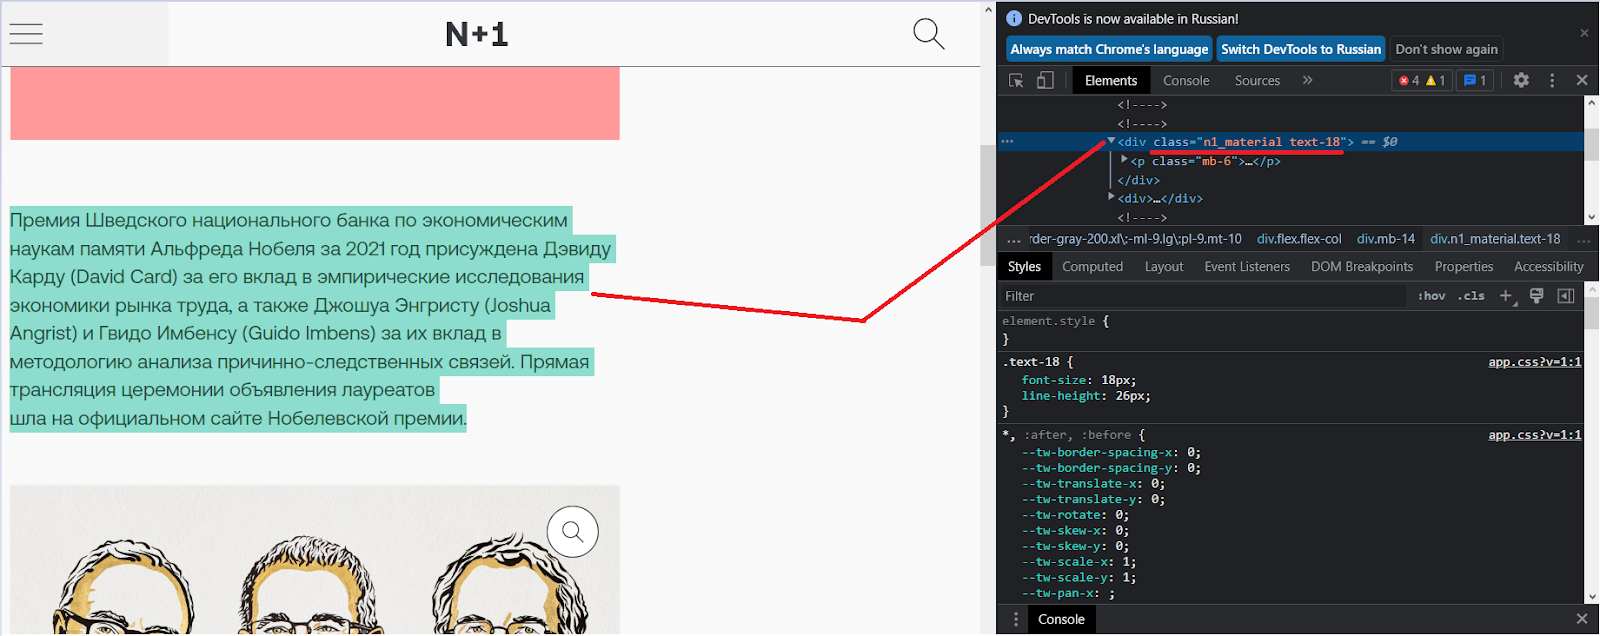

Передадим название класса в метод find() с помощью аргумента class_ и получим текст статьи:

In [ ]:
print(page.find('div', class_='n1_material text-18').text) # Выводим содержимое атрибута text тега div класса n1_material text-18

AttributeError: 'NoneType' object has no attribute 'text'

В данном случае происходит поиск точного строкового значения class атрибута, т. е. выполнение строк кода:
```python
print(page.find('div', class_='n1_material').text)
print(page.find('div', class_='n1_material text-18').text)
```
даст одинаковый результат.

При выполнении строки кода
```python
print(page.find('div', class_='text-18 n1_material').text)
```
мы получим ошибку, так как такого строкового значения в области поиска нет.

Аналогично получим информации о теге, который содержит дату написания статьи, отображаемую в левом верхнем углу страницы.
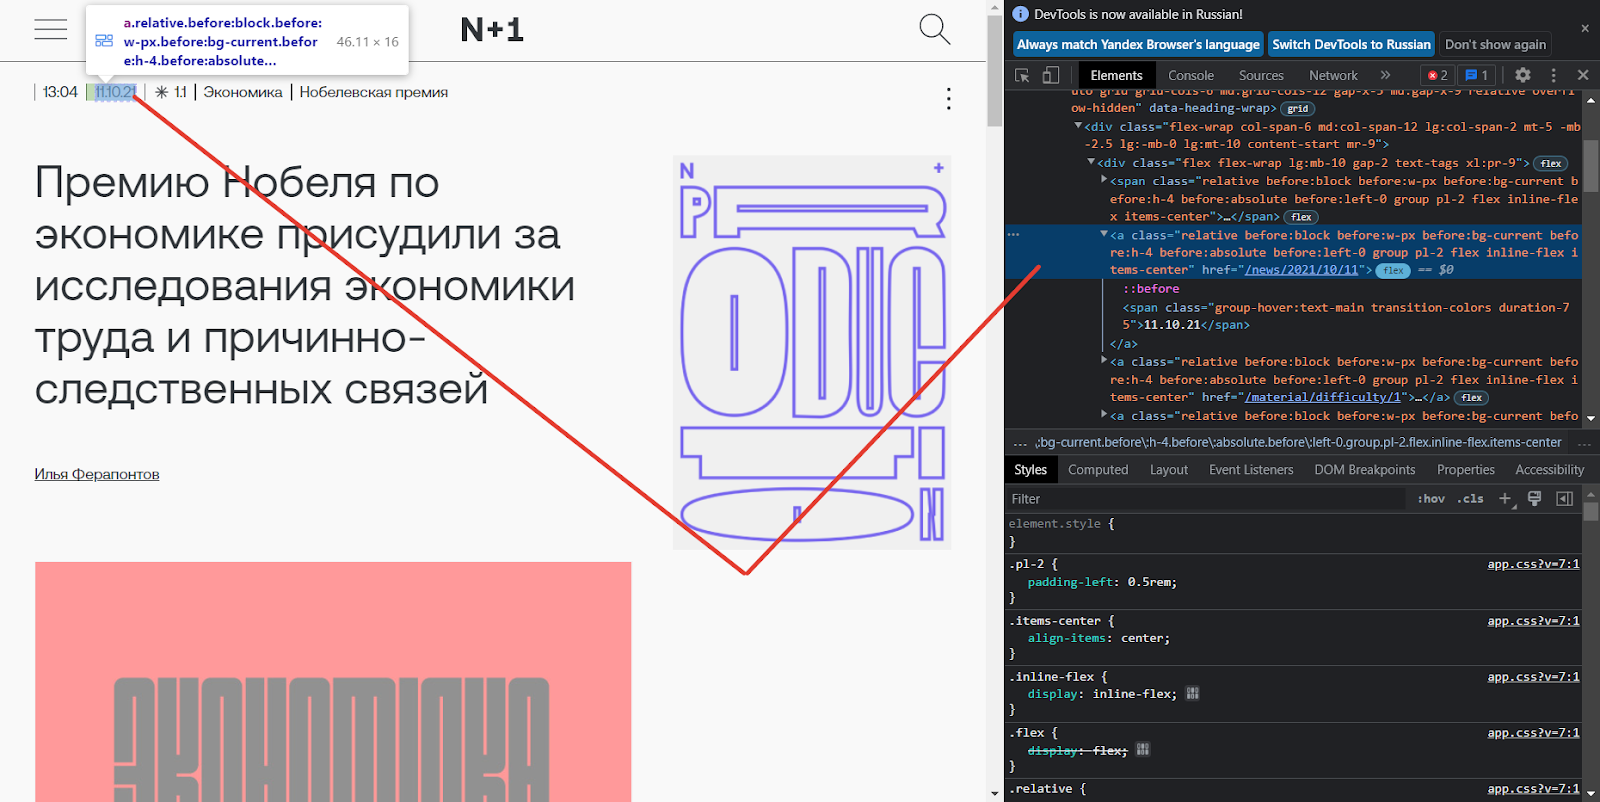

Итак, нам нужен тег ```<a> … </a>``` с классом ```"relative before:block before:w-px before:bg-current before:h-4 before:absolute before:left-0 group pl-2 flex inline-flex items-center"```. Для поиска достаточно указать в качестве класса "relative", отбросив дополнительные настройки.

Теперь получим данные из него с помощью уже известного метода find(), передав название нужного тега:

In [36]:
# Выводим на экран содержимое атрибута text тега a с классом "relative"
print(page.find('a', class_= "relative").text)

AttributeError: 'NoneType' object has no attribute 'text'

О поиске по классу можно узнать подробнее в [Beautiful Soup Documentation.](https://www.crummy.com/software/BeautifulSoup/bs4/doc/#searching-by-css-class)

In [40]:
import asyncio
import sys
from concurrent.futures import ThreadPoolExecutor

# Функция, которая будет выполняться в отдельном потоке с новым циклом
async def get_title_async():
    # Устанавливаем правильную политику для этого потока (Windows)
    if sys.platform == "win32":
        asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
    
    from playwright.async_api import async_playwright
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        await page.goto('https://nplus1.ru/news/2021/10/11/econobel2021')
        await page.wait_for_load_state('networkidle')
        title = await page.title()
        await browser.close()
        return title

# Обёртка для запуска асинхронной функции в новом цикле
def run_async_in_thread():
    # Создаём новый цикл событий
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    try:
        return loop.run_until_complete(get_title_async())
    finally:
        loop.close()

# Запускаем в отдельном потоке
with ThreadPoolExecutor(max_workers=1) as executor:
    future = executor.submit(run_async_in_thread)
    title = future.result()

print(title)

TimeoutError: Timeout 30000ms exceeded.
=========================== logs ===========================
"commit" event fired
"domcontentloaded" event fired
"load" event fired
"commit" event fired
"domcontentloaded" event fired
"load" event fired
============================================================

In [43]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "get_title_playwright.py"],
    capture_output=True,
    text=True,
    timeout=60  # таймаут на случай зависания
)

if result.returncode == 0:
    print("Заголовок:", result.stdout.strip())
else:
    print("Ошибка:", result.stderr)

Ошибка: ERROR: Timeout 30000ms exceeded.



## Сбор нескольких элементов: собираем все ссылки на странице

Рассмотрим ещё один сценарий: вы хотите собрать сразу несколько элементов со страницы. Например, представьте, что вы хотите получить названия всех языков программирования, упомянутых на странице в Wikipedia в статье про языки программирования.

Можно заметить, что все названия языков программирования на этой странице связаны ссылками c соответствующими статьями о них. Таким образом, нам необходимо собрать все ссылки на странице. Для ссылок в HTML предусмотрен тег ```<a> … </a>```. Попробуем использовать find():

In [ ]:
url = 'https://en.wikipedia.org/wiki/List_of_programming_languages' # Задаём адрес ресурса
response = requests.get(url) # Делаем GET-запрос к ресурсу
page = BeautifulSoup(response.text, 'html.parser') # Создаём объект BeautifulSoup
print(page.find('a')) # Ищем ссылку по тегу <a> и выводим её на экран

None


Мы получили только одну ссылку, хотя на странице их явно больше.

Это происходит, потому что метод ```find()``` возвращает только первый подходящий элемент. Если требуется получить больше элементов, необходимо воспользоваться методом ```find_all()``` (с англ. найти все):

In [ ]:
links = page.find_all('a') # Ищем все ссылки на странице и сохраняем в переменной links в виде списка
print(len(links)) # Выводим количество найденных ссылок

#928

0


Итак, на момент создания этих учебных материалов на странице содержалось 928 ссылок. Посмотрим на некоторые из них:

In [ ]:
print([link.text for link in links[500:510]]) # Выводим ссылки с 500 по 509 включительно

[]


Не все ссылки соответствуют названиям языков программирования — страница содержит также «служебные» ссылки, такие, например, как Jump to navigation (с англ. Перейти к навигации) или Alphabetical (с англ. По алфавиту):

In [ ]:
print([link.text for link in links[0:10]]) # Выводим ссылки с 1 по 9 включительно

[]


В заключение заметим, что BeautifulSoup — достаточно мощная библиотека. Мы рассмотрели её базовые возможности, но их полный список гораздо шире. С ним можно ознакомиться в [официальной документации](https://www.crummy.com/software/BeautifulSoup/bs4/doc/).